**Bank Marketing Campaign**


Context :
The types of financial products used by the public are more varied. One financial product that is well-known to the public is term deposits. The term deposit mechanism is that a customer deposits a sum of money at a bank or a financial institution, and the money can only be withdrawn after a certain period of time. As compensation, customers will be given a fixed interest according to the nominal amount of money deposited.

Nevertheless, as business entities with financial products and respective customers, banks still have to compete to not lose customers. One of the ways to acquire new customers is by conducting a marketing campaign.

Objectives :

- Predict whether a customer will subscribe (deposit = yes/no) based on the provided features.


#Libaries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data + Cleaning

In [5]:
df = pd.read_csv('data_bank_marketing_campaign.csv')
df

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...
7808,62,housemaid,2,no,no,cellular,nov,1,-1,unknown,yes
7809,48,housemaid,5473,no,no,cellular,feb,2,184,success,yes
7810,36,unknown,179,no,no,cellular,aug,8,-1,unknown,no
7811,31,admin.,54,yes,no,cellular,nov,1,-1,unknown,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


In [7]:
df.describe()

,age,balance,campaign,pdays
count,7813.000000,7813.000000,7813.000000,7813.000000
mean,41.257264,1512.448611,2.519775,51.408550
std,11.919710,3089.291831,2.727001,108.072739
min,18.000000,-6847.000000,1.000000,-1.000000
25%,32.000000,127.000000,1.000000,-1.000000
50%,39.000000,549.000000,2.000000,-1.000000
75%,49.000000,1684.000000,3.000000,40.000000
max,95.000000,66653.000000,63.000000,854.000000


In [8]:
#Check Data Loss
df.isnull().sum()

,0
age,0
job,0
balance,0
housing,0
loan,0
contact,0
month,0
campaign,0
pdays,0
poutcome,0


Tidak ada data yang hilang, maka tidak perlu mmelengakpi data atau menghapus data.



Processing column: balance


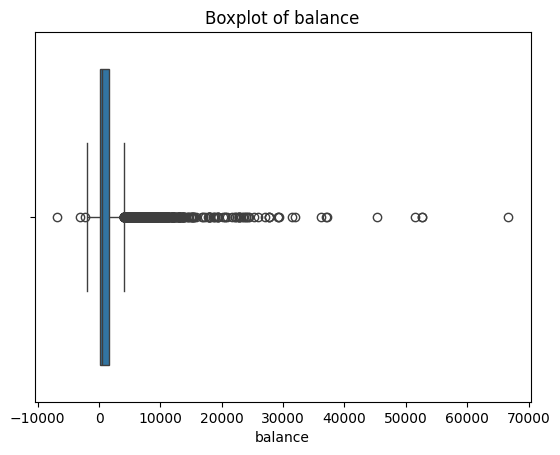

Outliers detected: 736
Capping values below -2208.50 and above 4019.50


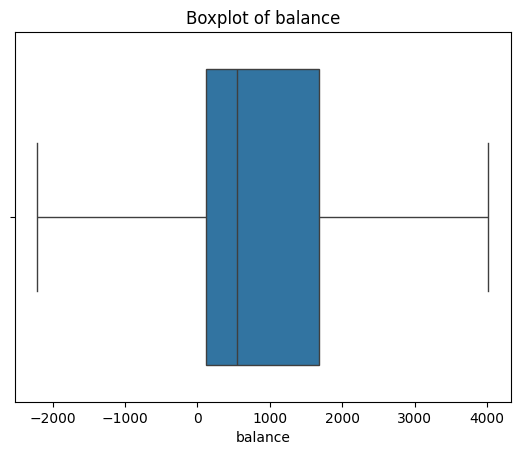


Processing column: campaign


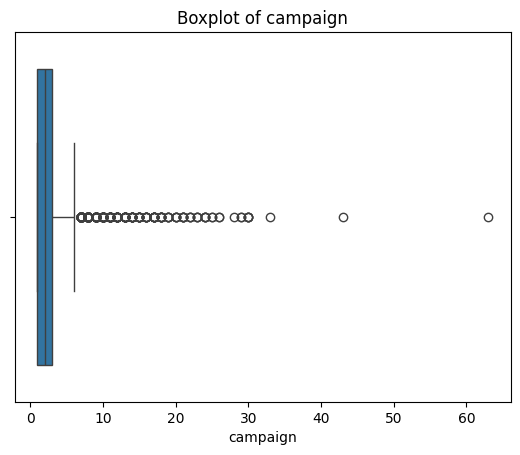

Outliers detected: 429
Capping values below -2.00 and above 6.00


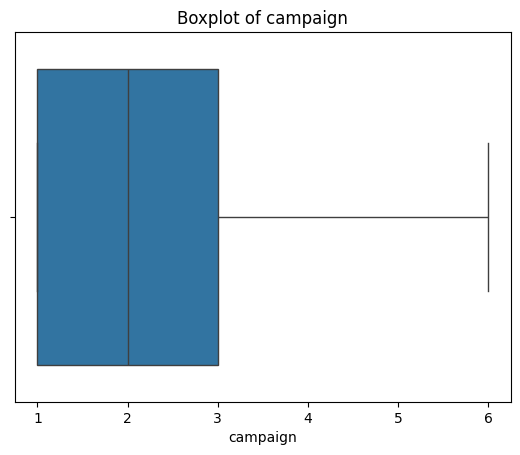


Processing column: pdays


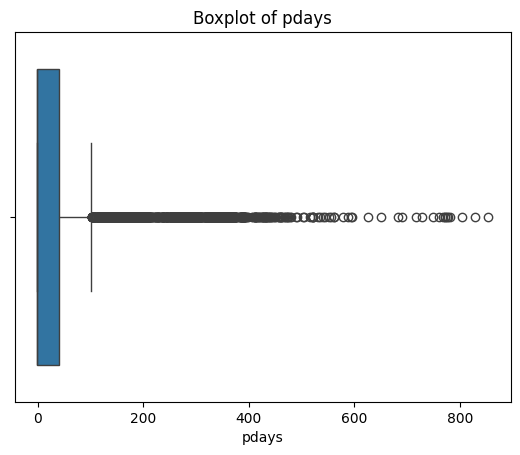

Outliers detected: 1454
Capping values below -62.50 and above 101.50


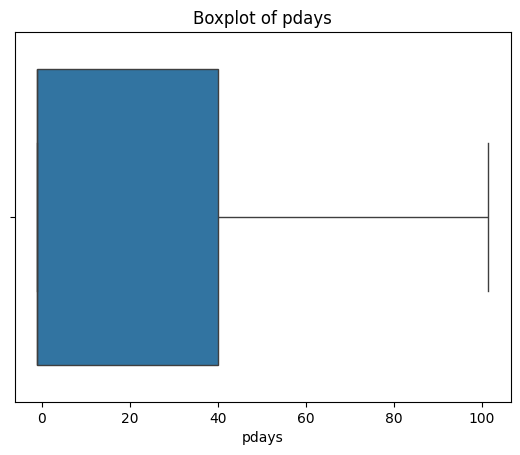

In [10]:
#Outlier Check
# Boxplot to visualize outliers
def plot_box(column):
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Outlier detection using IQR
def detect_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Cap outliers function (Winsorizing)
def cap_outliers(column):
    outliers, lower, upper = detect_outliers_iqr(column)
    df[column] = np.where(df[column] > upper, upper,
                          np.where(df[column] < lower, lower, df[column]))

# Plot and cap each column
for col in ['balance', 'campaign', 'pdays']:
    print(f"\nProcessing column: {col}")
    plot_box(col)
    outliers, low, high = detect_outliers_iqr(col)
    print(f"Outliers detected: {len(outliers)}")
    print(f"Capping values below {low:.2f} and above {high:.2f}")
    cap_outliers(col)
    plot_box(col)  # Plot again after capping

# Optional: create a new feature for pdays = -1
df['contacted_before'] = df['pdays'].apply(lambda x: 0 if x == -1 else 1)

In [11]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_cleaned = df[(df['balance'] >= lower) & (df['balance'] <= upper)]

In [12]:
df_cleaned.describe()

,age,balance,campaign,pdays,contacted_before
count,7813.000000,7813.000000,7813.000000,7813.000000,7813.000000
mean,41.257264,1101.699219,2.247280,23.879048,0.255472
std,11.919710,1327.156943,1.530299,43.092996,0.436154
min,18.000000,-2208.500000,1.000000,-1.000000,0.000000
25%,32.000000,127.000000,1.000000,-1.000000,0.000000
50%,39.000000,549.000000,2.000000,-1.000000,0.000000
75%,49.000000,1684.000000,3.000000,40.000000,1.000000
max,95.000000,4019.500000,6.000000,101.500000,1.000000


#EDA

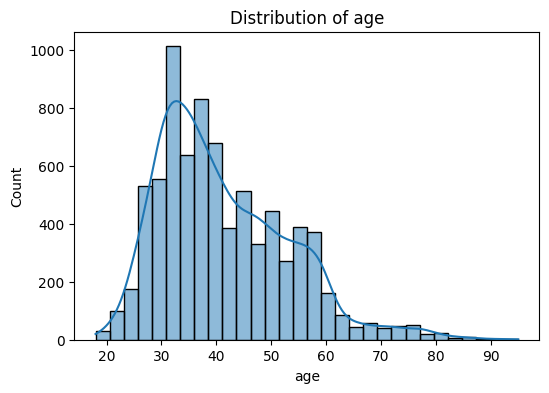

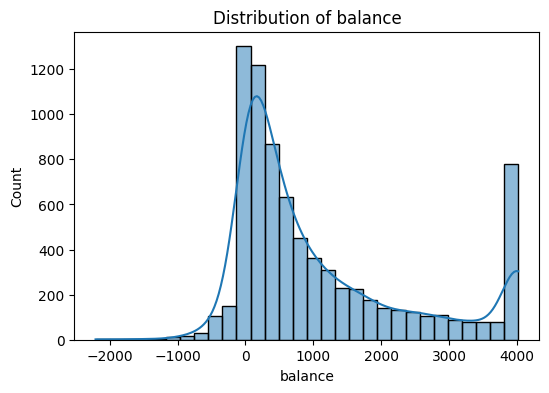

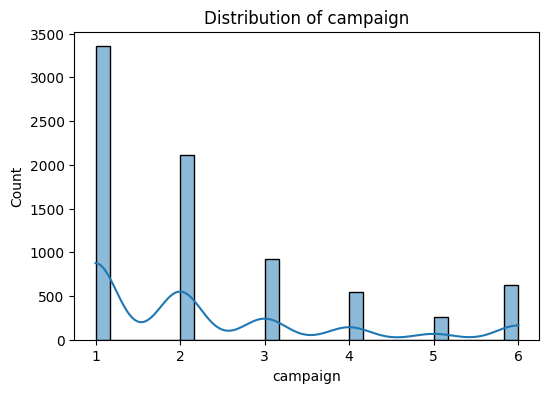

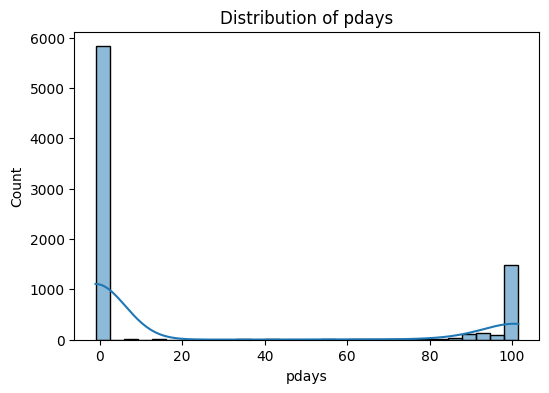

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['age', 'balance', 'campaign', 'pdays']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Penjelasan :
- Distribusi by age :  distribusi umur  dapat dipastikan usa 30 - 50 tahun adalah yang paling banyak
- Distribusi by balance : distribusi balance dapat dipatkan rentang terbanyak adalah 0 hingga 1000
- Distribusi by Campaign : Mayoritas kontak hanya dilakukan 1 kali. Terlihat bahwa campaign dengan jumlah 1 kali kontak paling sering terjadi (sekitar 3300 kali).Kontak kedua (2 kali) juga cukup banyak, namun jauh lebih sedikit dibanding satu kali.
- Distribusi by p days : banyak client yang tidak kembali setelah di kontak


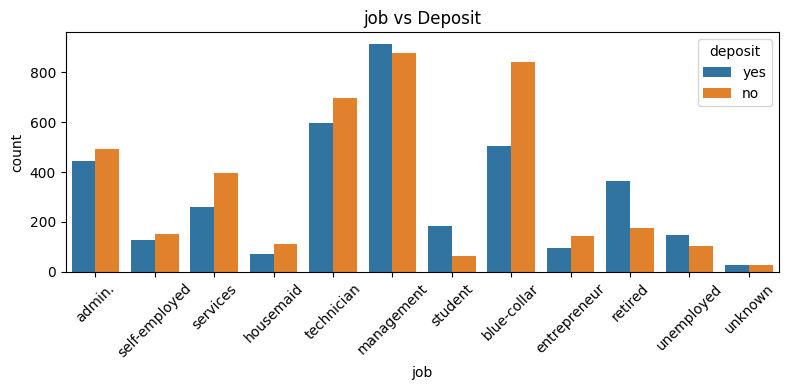

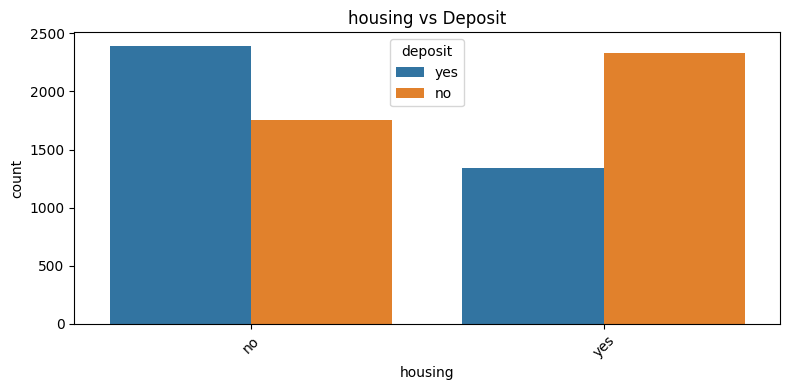

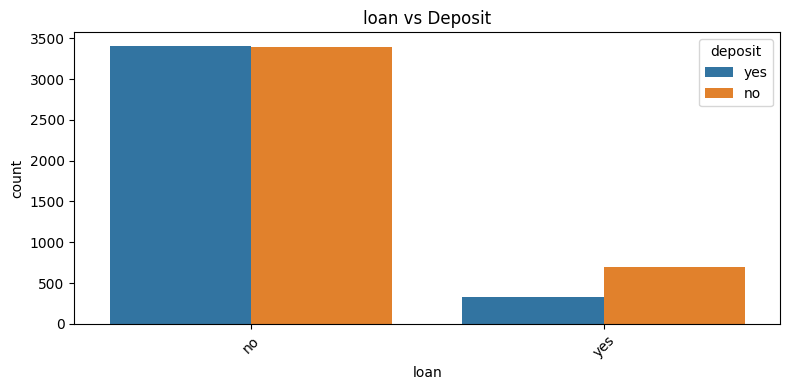

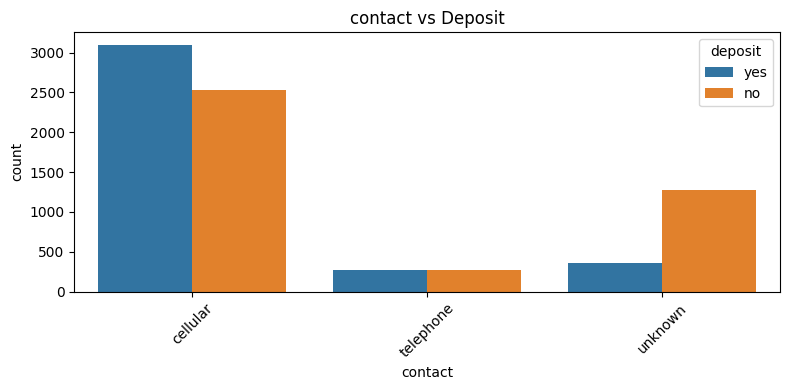

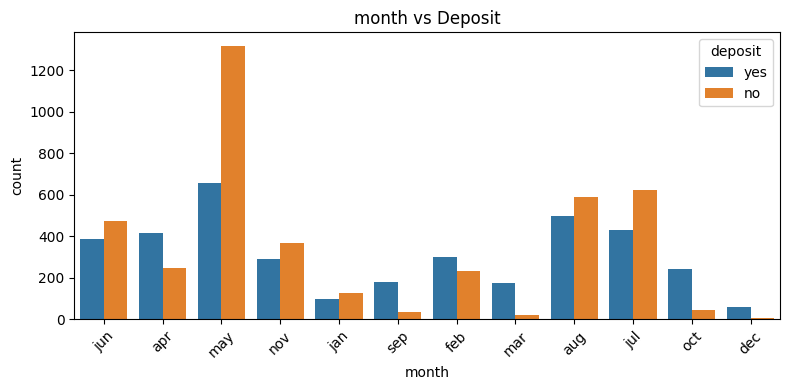

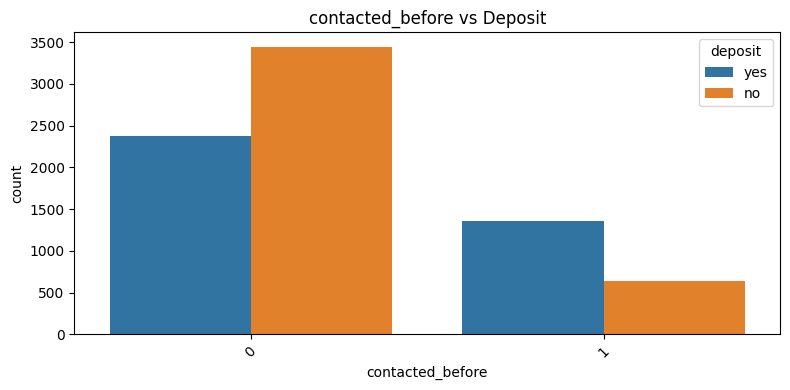

In [14]:
#Bar Plot
cat_cols = ['job', 'housing', 'loan', 'contact', 'month', 'contacted_before']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='deposit')
    plt.title(f'{col} vs Deposit')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

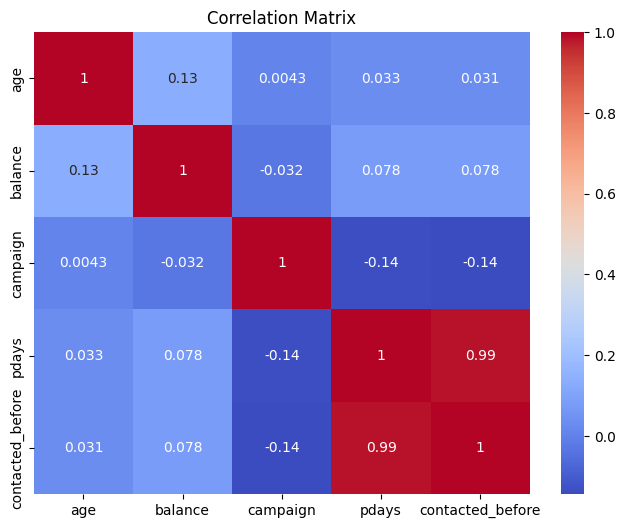

In [17]:
#Corr Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['contacted_before']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

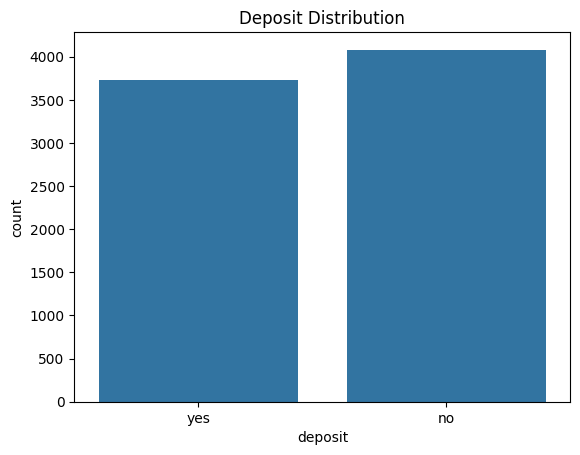

deposit
no     0.522335
yes    0.477665
Name: proportion, dtype: float64


In [18]:
sns.countplot(data=df, x='deposit')
plt.title('Deposit Distribution')
plt.show()

print(df['deposit'].value_counts(normalize=True))


# Modelling + Result

In [19]:
# Cross validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Split data & encode
X = df_cleaned.drop(columns=['deposit'])
y = df_cleaned['deposit']

In [20]:
# One-hot encoding untuk semua kolom kategori
X_encoded = pd.get_dummies(X, drop_first=True)

# Split data untuk prediksi akhir setelah CV
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [23]:
# ⛏️ Encoding target
y = y.map({'no': 0, 'yes': 1})

In [24]:
# 2. Definisikan semua model dengan pipeline jika perlu
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


In [25]:
# 3. Cross-validation tiap model
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_encoded, y, cv=5, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name} - Mean Accuracy: {scores.mean():.4f}")


Logistic Regression - Mean Accuracy: 0.7052
Random Forest - Mean Accuracy: 0.7015


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:16:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:16:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:16:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:16:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Mean Accuracy: 0.7048


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [05:16:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [26]:
# 4. Pilih model terbaik
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n✅ Model terbaik berdasarkan cross-validation: {best_model_name}")


✅ Model terbaik berdasarkan cross-validation: Logistic Regression


In [27]:
# 5. Latih ulang di training set
best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000))])

In [28]:
# 6. Prediksi & evaluasi di test set
y_pred = best_model.predict(X_test)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

          no       0.68      0.80      0.74       814
         yes       0.73      0.60      0.66       749

    accuracy                           0.70      1563
   macro avg       0.71      0.70      0.70      1563
weighted avg       0.71      0.70      0.70      1563



Result :
- Model lebih cenderung aman → lebih banyak nebak "no"

- Banyak pelanggan yang seharusnya "yes" (deposit) tidak terdeteksi

- Jika ingin membuat kampanye marketing dari hasil ini, maka bisa kehilangan calon nasabah potensial yang sebenarnya berminat

#Apakah ada Imbalance?

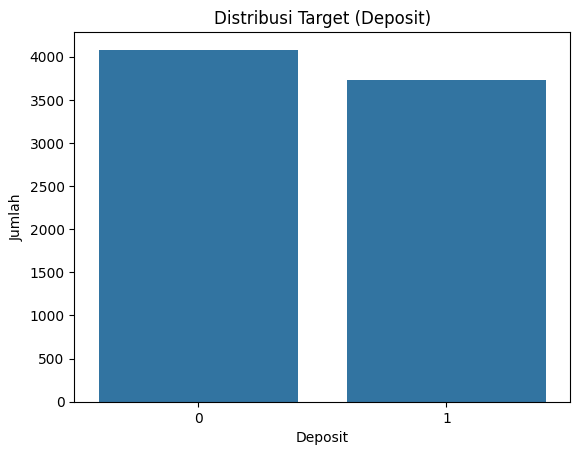

deposit
0    0.522335
1    0.477665
Name: proportion, dtype: float64


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cek distribusi label
sns.countplot(x=y)
plt.title("Distribusi Target (Deposit)")
plt.xlabel("Deposit")
plt.ylabel("Jumlah")
plt.show()

# Persentase
print(y.value_counts(normalize=True))


tidak ada imbalance

#Oversampling by SMOTE

In [31]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE ke training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE:")
print(y_resampled.value_counts())


Setelah SMOTE:
deposit
yes    3267
no     3267
Name: count, dtype: int64


In [32]:
model_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

model_smote.fit(X_resampled, y_resampled)
y_pred_smote = model_smote.predict(X_test)

print("\n📊 Classification Report setelah SMOTE:")
print(classification_report(y_test, y_pred_smote))


📊 Classification Report setelah SMOTE:
              precision    recall  f1-score   support

          no       0.69      0.79      0.74       814
         yes       0.73      0.61      0.67       749

    accuracy                           0.70      1563
   macro avg       0.71      0.70      0.70      1563
weighted avg       0.71      0.70      0.70      1563



Hasilnya: recall untuk 'yes' naik dari 60% → 61%.
Artinya model jadi lebih peka terhadap pelanggan yang melakukan deposit.

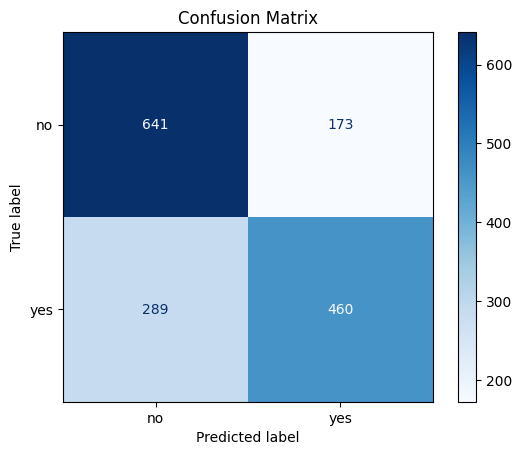

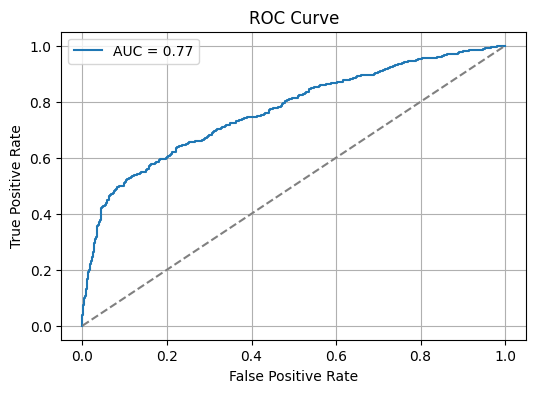

In [34]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
y_probs = model_smote.predict_proba(X_test)[:, 1]  # Probabilitas class 1
y_test = y_test.map({'no': 0, 'yes': 1})
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Hasil Confusion Matrix:

 Penjelasan:
* True Negative (TN): 641 — pelanggan yang memang tidak deposit, dan diprediksi tidak deposit.

* False Positive (FP): 173 — pelanggan diprediksi akan deposit, padahal tidak.

* False Negative (FN): 289 — pelanggan diprediksi tidak deposit, padahal akan deposit (ini penting).

* True Positive (TP): 460 — pelanggan yang diprediksi akan deposit, dan benar deposit.

Insight:
* Model cukup baik dalam mengenali pelanggan tidak deposit (641 vs 173).

* Masih ada 289 nasabah yang tertarik deposit tapi gagal terdeteksi → ini bisa jadi peluang kampanye lanjutan!

Hasil ROC Curve dan AUC

ROC Curve mengukur kemampuan model membedakan class 'yes' vs 'no'.

AUC = 1 → sempurna
AUC = 0.5 → tebak-tebakan AUC = 0.77 → bagus, jauh lebih baik dari random.